# Proyecto final integrador — Fase 4

## Condiciones operacionales asociadas con fallas en AI4I 2020

**MCDI500 — Programación para la Ciencia de Datos**  
**Estudiante:** Alexander Sepúlveda Ormazábal  
**Grupo:** 9  
**Fecha:** 4 de octubre de 2026

Este cuaderno integra las cuatro fases del proyecto. Utiliza los productos ya
validados en F3, recupera una versión interpretable de los datos y presenta los
hallazgos mediante tablas y visualizaciones. El propósito no es repetir la
limpieza ni el escalamiento, sino cerrar el análisis y comunicar sus límites.


## 1. Continuidad del proyecto

La pregunta definida en F1 fue: **¿qué condiciones operacionales están
asociadas con la ocurrencia de fallas en maquinaria industrial y en qué medida
estas variables permiten identificar situaciones de riesgo de falla?**

El objetivo general definido en F1 fue **analizar la relación entre las
condiciones operacionales de la maquinaria industrial y la ocurrencia de
fallas mediante AI4I 2020, con el propósito de identificar posibles patrones
de riesgo y evaluar posteriormente la capacidad de estas variables para
anticipar fallas**. F2 preparó los datos y F3 reorganizó ese mismo pipeline
mediante funciones, clases y módulos. En F4 la identificación de patrones se
evalúa de forma exploratoria; como no se entrena un modelo, no se estima una
capacidad predictiva formal. El cierre responde tres preguntas:

1. ¿Cómo se distribuye la ocurrencia de fallas en el conjunto?
2. ¿Qué diferencias se observan según el tipo de producto y las cinco
   variables operacionales?
3. ¿Qué combinaciones de velocidad, torque y desgaste concentran una mayor
   tasa de fallas?

El análisis es descriptivo. Por ello, los resultados muestran asociaciones en
un conjunto sintético y no demuestran causalidad ni desempeño predictivo en
maquinaria real. Esta distinción es relevante porque el mantenimiento
predictivo suele combinar monitoreo de condición y técnicas de aprendizaje
automático, cuya utilidad debe evaluarse con métricas apropiadas (Phan et al.,
2022).


## 2. Entorno reproducible

Primero se registran el intérprete, las versiones y la semilla. Esta evidencia
permite comprobar que el cuaderno se ejecutó con el entorno virtual del
proyecto y que las operaciones aleatorias pueden repetirse.


In [1]:
import hashlib
import json
import platform
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from pandas.testing import assert_frame_equal

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.frameon": False,
})

print("Fase 4 · Grupo 9 ·", date.today().isoformat())
print("Intérprete:", sys.executable)
print("Entorno virtual activo:", sys.prefix != sys.base_prefix)
print("Sistema:", platform.platform())
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("Semilla:", SEMILLA)


Fase 4 · Grupo 9 · 2026-10-04
Intérprete: C:\proyecto-grupo9-mcdi500\.venv\Scripts\python.exe
Entorno virtual activo: True
Sistema: Windows-11-10.0.26200-SP0
Python: 3.13.0
NumPy: 2.5.3
pandas: 3.0.5
Matplotlib: 3.11.2
seaborn: 0.13.2
scikit-learn: 1.9.1
Semilla: 42


### 2.1 Rutas del proyecto

Las rutas se construyen desde la raíz del repositorio. De esta forma, el
cuaderno no depende de una carpeta personal y puede ejecutarse desde la raíz o
desde `F4`.


In [2]:
def encontrar_raiz(inicio):
    '''Busca la raíz por la presencia del README y las carpetas F1, F2 y F3.'''
    inicio = Path(inicio).resolve()
    for candidata in [inicio, *inicio.parents]:
        if (
            (candidata / "README.md").is_file()
            and (candidata / "F1").is_dir()
            and (candidata / "F2").is_dir()
            and (candidata / "F3").is_dir()
        ):
            return candidata
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


RAIZ = encontrar_raiz(Path.cwd())
CARPETA_F4 = RAIZ / "F4"
CARPETA_DATOS = CARPETA_F4 / "data" / "processed"
CARPETA_DOCS = CARPETA_F4 / "docs"
CARPETA_FIGURAS = CARPETA_F4 / "figuras"

for carpeta in (CARPETA_DATOS, CARPETA_DOCS, CARPETA_FIGURAS):
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {
    "crudo": RAIZ / "F1" / "data" / "raw" / "ai4i2020.csv",
    "entrenamiento": RAIZ / "F3" / "data" / "processed" / "ai4i2020_entrenamiento_procesado.csv",
    "prueba": RAIZ / "F3" / "data" / "processed" / "ai4i2020_prueba_procesado.csv",
    "diccionario": RAIZ / "F3" / "data" / "processed" / "diccionario_f3.csv",
    "parametros": RAIZ / "F3" / "data" / "processed" / "parametros_f3.csv",
}

EVIDENCIAS_F3 = {
    "comparacion_eficiencia": RAIZ / "F3" / "docs" / "comparacion_eficiencia.csv",
    "crecimiento_temporal": RAIZ / "F3" / "docs" / "crecimiento_temporal.csv",
    "arquitectura": RAIZ / "F3" / "docs" / "arquitectura_fase3.csv",
    "notebook": RAIZ / "F3" / "S2_F3_NucleoAlgoritmico_Eficiencia_POO.ipynb",
}

print("Raíz:", RAIZ)
for nombre, ruta in ARCHIVOS.items():
    print(f"{nombre:15} {ruta.relative_to(RAIZ)}")


Raíz: C:\proyecto-grupo9-mcdi500
crudo           F1\data\raw\ai4i2020.csv
entrenamiento   F3\data\processed\ai4i2020_entrenamiento_procesado.csv
prueba          F3\data\processed\ai4i2020_prueba_procesado.csv
diccionario     F3\data\processed\diccionario_f3.csv
parametros      F3\data\processed\parametros_f3.csv


## 3. Integración de los productos de F3

F4 recibe cuatro artefactos: entrenamiento, prueba, diccionario y parámetros.
El archivo original de F1 se utiliza como referencia de control de integridad
para verificar que la reconstrucción conserve las observaciones y sus unidades.


In [3]:
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from F3.src.carga import cargar_csv

datos_crudos = cargar_csv(ARCHIVOS["crudo"], "Datos originales de F1")
entrenamiento_f3 = cargar_csv(ARCHIVOS["entrenamiento"], "Entrenamiento de F3")
prueba_f3 = cargar_csv(ARCHIVOS["prueba"], "Prueba de F3")
diccionario_f3 = cargar_csv(ARCHIVOS["diccionario"], "Diccionario de F3")
parametros_f3 = cargar_csv(ARCHIVOS["parametros"], "Parámetros de F3")

print("\nArtefactos de transición cargados:", 4)


Datos originales de F1: 10000 filas x 14 columnas
Entrenamiento de F3: 8000 filas x 9 columnas
Prueba de F3: 2000 filas x 9 columnas
Diccionario de F3: 9 filas x 5 columnas
Parámetros de F3: 6 filas x 4 columnas

Artefactos de transición cargados: 4


### 3.1 Verificación de entradas

Antes del análisis se comprueban dimensiones, columnas, variable objetivo y
ausencia de nulos nuevos. Si una condición no se cumple, la ejecución se
detiene en este punto en lugar de producir gráficos incorrectos.


In [4]:
COLUMNAS_MODELO = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_H",
    "Type_L",
    "Type_M",
    "Machine failure",
]

assert entrenamiento_f3.shape == (8000, 9)
assert prueba_f3.shape == (2000, 9)
assert list(entrenamiento_f3.columns) == COLUMNAS_MODELO
assert list(prueba_f3.columns) == COLUMNAS_MODELO
assert entrenamiento_f3.isna().sum().sum() == 0
assert prueba_f3.isna().sum().sum() == 0
assert len(diccionario_f3) == 9
assert len(parametros_f3) == 6
assert entrenamiento_f3["Machine failure"].sum() == 271
assert prueba_f3["Machine failure"].sum() == 68

controles_entrada = pd.DataFrame({
    "control": [
        "Entrenamiento",
        "Prueba",
        "Columnas comunes",
        "Diccionario",
        "Parámetros",
        "Fallas conservadas",
    ],
    "resultado": [
        "8.000 x 9",
        "2.000 x 9",
        "9 de 9",
        "9 variables",
        "6 pasos",
        "271 + 68 = 339",
    ],
    "estado": ["OK"] * 6,
})
display(controles_entrada)


,control,resultado,estado
0,Entrenamiento,8.000 x 9,OK
1,Prueba,2.000 x 9,OK
2,Columnas comunes,9 de 9,OK
3,Diccionario,9 variables,OK
4,Parámetros,6 pasos,OK
5,Fallas conservadas,271 + 68 = 339,OK


### 3.2 Continuidad de la arquitectura de F3

F4 no redefine las clases. Se importan los componentes existentes para
comprobar que la arquitectura continúa disponible. La fábrica crea el tipo de
transformador solicitado y ambas clases conservan el contrato común de
`Transformador`.


In [5]:
from F3.src.fabrica import FabricaTransformadores
from F3.src.pipeline import Pipeline
from F3.src.transformadores import Transformador

paso_categorico = FabricaTransformadores.crear("categorica", "Type")
paso_numerico = FabricaTransformadores.crear("numerica", "Torque [Nm]")

assert isinstance(paso_categorico, Transformador)
assert isinstance(paso_numerico, Transformador)
assert hasattr(Pipeline, "ajustar") and hasattr(Pipeline, "transformar")

continuidad_poo = pd.DataFrame([
    {
        "elemento": type(paso_categorico).__name__,
        "función": "Codificar Type en el pipeline de F3 mediante el contrato común",
        "principio": "Herencia y polimorfismo",
    },
    {
        "elemento": type(paso_numerico).__name__,
        "función": "Conservar parámetros aprendidos en el ajuste",
        "principio": "Encapsulamiento por convención y guardas",
    },
    {
        "elemento": "Pipeline",
        "función": "Recorrer pasos sin conocer su implementación interna",
        "principio": "Bajo acoplamiento",
    },
])
display(continuidad_poo)


,elemento,función,principio
0,CodificadorOneHot,Codificar Type en el pipeline de F3 mediante e...,Herencia y polimorfismo
1,EscaladorRobusto,Conservar parámetros aprendidos en el ajuste,Encapsulamiento por convención y guardas
2,Pipeline,Recorrer pasos sin conocer su implementación i...,Bajo acoplamiento


### 3.3 Evidencia resumida de pruebas y eficiencia de F3

El cuaderno consolidado no repite las mediciones de F3, porque su objetivo es
integrar productos ya comprobados. En cambio, carga las tablas guardadas y lee
los mensajes de las pruebas ejecutadas. Esto deja visible que se evaluaron un
caso normal, un caso límite, dos excepciones, el tiempo, la memoria y el
crecimiento para cuatro tamaños de muestra.


In [6]:
for nombre, ruta in EVIDENCIAS_F3.items():
    if not ruta.is_file():
        raise FileNotFoundError(f"Falta evidencia de F3: {ruta.relative_to(RAIZ)}")

comparacion_eficiencia = pd.read_csv(EVIDENCIAS_F3["comparacion_eficiencia"])
crecimiento_temporal = pd.read_csv(EVIDENCIAS_F3["crecimiento_temporal"])
arquitectura_f3 = pd.read_csv(EVIDENCIAS_F3["arquitectura"])

cuaderno_f3 = json.loads(EVIDENCIAS_F3["notebook"].read_text(encoding="utf-8"))
lineas_pruebas = []
for celda in cuaderno_f3["cells"]:
    for salida in celda.get("outputs", []):
        texto = "".join(salida.get("text", []))
        lineas_pruebas.extend(
            linea.strip()
            for linea in texto.splitlines()
            if linea.strip().startswith("[OK]")
        )

controles_pruebas = {
    "Caso normal": any("Caso normal" in linea for linea in lineas_pruebas),
    "Caso límite": any("Caso límite" in linea for linea in lineas_pruebas),
    "Excepción: pipeline sin ajustar": any("falta de ajuste" in linea for linea in lineas_pruebas),
    "Excepción: categoría desconocida": any("categoría desconocida" in linea for linea in lineas_pruebas),
    "Equivalencia F3 con F2": any("coinciden con F2" in linea for linea in lineas_pruebas),
}
pruebas_f3 = pd.DataFrame([
    {"prueba": nombre, "estado": "OK" if resultado else "FALTA"}
    for nombre, resultado in controles_pruebas.items()
])

assert pruebas_f3["estado"].eq("OK").all()
assert set(crecimiento_temporal["filas"]) == {1000, 5000, 10000, 20000}
assert set(comparacion_eficiencia["implementacion"]) == {"Funcional", "POO modular"}

display(pruebas_f3)
display(comparacion_eficiencia.round(4))
display(crecimiento_temporal.round(3))
print(
    "[OK] F3 conserva equivalencia, pruebas controladas y mediciones para cuatro tamaños."
)


,prueba,estado
0,Caso normal,OK
1,Caso límite,OK
2,Excepción: pipeline sin ajustar,OK
3,Excepción: categoría desconocida,OK
4,Equivalencia F3 con F2,OK


,implementacion,tiempo_promedio_s,tiempo_minimo_s,memoria_pico_mib
0,Funcional,0.0133,0.0115,0.6631
1,POO modular,0.0373,0.0352,1.2393


,filas,funcional_ms,poo_ms,razon_poo_funcional
0,1000,3.165,9.416,2.975
1,5000,4.463,18.313,4.103
2,10000,4.648,12.747,2.742
3,20000,6.894,14.601,2.118


[OK] F3 conserva equivalencia, pruebas controladas y mediciones para cuatro tamaños.


**Interpretación sencilla.** Las dos implementaciones entregaron el mismo
resultado. La versión funcional fue más rápida y usó menos memoria en esta
medición, mientras la versión orientada a objetos aportó modularidad y
reutilización. Los tiempos aumentan en el orden de milisegundos al crecer la
muestra, lo que es compatible con un recorrido aproximadamente lineal. La
decisión de conservar la versión modular responde a la mantenibilidad, no a que
sea la alternativa más rápida en este conjunto.


## 4. Preparación del conjunto interpretable

Los CSV de F3 son adecuados para algoritmos, pero sus variables numéricas están
escaladas y `Type` está representada por tres columnas binarias. Para graficar
se construye una copia interpretable:

- se recupera cada unidad con `original = escalado × IQR + mediana`;
- se reconstruye `Type` a partir de la única columna One Hot activa;
- se conserva `Machine failure` sin transformarla;
- se agrega `particion` para mantener la trazabilidad de entrenamiento y prueba.

No se vuelve a ajustar ningún escalador.


In [7]:
COLUMNAS_NUMERICAS = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
COLUMNAS_TYPE = ["Type_H", "Type_L", "Type_M"]
OBJETIVO = "Machine failure"


def leer_parametros(texto):
    '''Convierte "mediana=...; iqr=..." en un diccionario numérico.'''
    resultado = {}
    for parte in texto.split(";"):
        clave, valor = parte.strip().split("=", 1)
        resultado[clave] = float(valor)
    return resultado


def reconstruir_interpretable(datos, particion, tabla_parametros):
    '''Recupera categorías y unidades originales desde un producto de F3.'''
    salida = datos.copy()

    suma_one_hot = salida[COLUMNAS_TYPE].sum(axis=1)
    if not suma_one_hot.eq(1).all():
        raise ValueError("Cada fila debe tener una sola categoría Type activa.")

    salida["Type"] = (
        salida[COLUMNAS_TYPE]
        .idxmax(axis=1)
        .str.replace("Type_", "", regex=False)
    )

    filas_escalador = tabla_parametros.query(
        "transformador == 'EscaladorRobusto'"
    )
    for _, fila in filas_escalador.iterrows():
        columna = fila["columna"]
        parametros = leer_parametros(fila["parametros_aprendidos"])
        salida[columna] = (
            salida[columna] * parametros["iqr"] + parametros["mediana"]
        )

    salida["Air temperature [K]"] = salida["Air temperature [K]"].round(1)
    salida["Process temperature [K]"] = salida["Process temperature [K]"].round(1)
    salida["Rotational speed [rpm]"] = salida["Rotational speed [rpm]"].round().astype("int64")
    salida["Torque [Nm]"] = salida["Torque [Nm]"].round(1)
    salida["Tool wear [min]"] = salida["Tool wear [min]"].round().astype("int64")
    salida[OBJETIVO] = salida[OBJETIVO].astype("int8")
    salida["particion"] = particion

    return salida[[
        "Type",
        *COLUMNAS_NUMERICAS,
        OBJETIVO,
        "particion",
    ]]


visual_entrenamiento = reconstruir_interpretable(
    entrenamiento_f3, "entrenamiento", parametros_f3
)
visual_prueba = reconstruir_interpretable(
    prueba_f3, "prueba", parametros_f3
)

df_visual = pd.concat(
    [visual_entrenamiento, visual_prueba],
    ignore_index=True,
)
df_visual["Estado"] = np.where(
    df_visual[OBJETIVO].eq(1), "Con falla", "Sin falla"
)

print("Conjunto interpretable:", df_visual.shape)
display(df_visual.head())


Conjunto interpretable: (10000, 9)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,particion,Estado
0,M,302.0,310.9,1456,47.2,54,0,entrenamiento,Sin falla
1,M,297.0,308.3,1399,46.4,132,0,entrenamiento,Sin falla
2,M,301.0,311.6,1357,45.6,137,0,entrenamiento,Sin falla
3,L,298.9,309.8,1411,56.3,84,0,entrenamiento,Sin falla
4,L,297.1,308.5,1733,28.7,50,0,entrenamiento,Sin falla


### 4.1 Validación de la reconstrucción

La comparación no utiliza el orden de las filas, porque F3 conserva la
separación entrenamiento/prueba pero no el índice original. Se ordenan las
siete variables analíticas antes de comparar. En términos simples, se comprueba
que sean las mismas 10.000 filas, aunque estén en otro orden, y que la inversión
no haya agregado, perdido ni cambiado observaciones.


In [8]:
COLUMNAS_ANALITICAS = ["Type", *COLUMNAS_NUMERICAS, OBJETIVO]

referencia = datos_crudos[COLUMNAS_ANALITICAS].copy()
referencia["Rotational speed [rpm]"] = referencia["Rotational speed [rpm]"].astype("int64")
referencia["Tool wear [min]"] = referencia["Tool wear [min]"].astype("int64")
referencia[OBJETIVO] = referencia[OBJETIVO].astype("int8")

referencia_ordenada = (
    referencia.sort_values(COLUMNAS_ANALITICAS, kind="mergesort")
    .reset_index(drop=True)
)
visual_ordenado = (
    df_visual[COLUMNAS_ANALITICAS]
    .sort_values(COLUMNAS_ANALITICAS, kind="mergesort")
    .reset_index(drop=True)
)

assert_frame_equal(
    visual_ordenado,
    referencia_ordenada,
    check_dtype=False,
    rtol=1e-12,
    atol=1e-12,
)

assert len(df_visual) == 10000
assert df_visual.isna().sum().sum() == 0
assert set(df_visual["Type"].unique()) == {"H", "L", "M"}
assert df_visual[OBJETIVO].sum() == 339

validacion_visual = pd.DataFrame([
    ["Filas recuperadas", len(df_visual), 10000, "OK"],
    ["Valores faltantes", int(df_visual.isna().sum().sum()), 0, "OK"],
    ["Categorías Type", ", ".join(sorted(df_visual["Type"].unique())), "H, L, M", "OK"],
    ["Registros con falla", int(df_visual[OBJETIVO].sum()), 339, "OK"],
    ["Equivalencia con F1", "mismas filas", "mismas filas", "OK"],
], columns=["control", "observado", "esperado", "estado"])

display(validacion_visual)
print("[OK] La copia interpretable conserva las observaciones de F1.")


,control,observado,esperado,estado
0,Filas recuperadas,10000,10000,OK
1,Valores faltantes,0,0,OK
2,Categorías Type,"H, L, M","H, L, M",OK
3,Registros con falla,339,339,OK
4,Equivalencia con F1,mismas filas,mismas filas,OK


[OK] La copia interpretable conserva las observaciones de F1.


## 5. Exploración dirigida por los objetivos

La exploración comienza con la variable objetivo y luego compara los grupos
según `Type` y las cinco mediciones operacionales. Las tablas conservan los
tamaños de cada grupo para evitar interpretar porcentajes sin conocer cuántas
observaciones los sostienen.

La `diferencia_estandarizada` resta las medias de los grupos con y sin falla y
divide el resultado por la desviación del conjunto. Aquí solo ayuda a ordenar
qué variables muestran separaciones más visibles: no es una prueba de
significancia ni demuestra causalidad.


In [9]:
ORDEN_ESTADO = ["Sin falla", "Con falla"]

resumen_objetivo = (
    df_visual.groupby("Estado", observed=True)
    .size()
    .reindex(ORDEN_ESTADO)
    .rename("registros")
    .to_frame()
)
resumen_objetivo["porcentaje"] = (
    resumen_objetivo["registros"] / len(df_visual) * 100
).round(2)

tasas_tipo = (
    df_visual.groupby("Type", observed=True)[OBJETIVO]
    .agg(registros="size", fallas="sum", tasa="mean")
    .assign(tasa_pct=lambda tabla: (tabla["tasa"] * 100).round(2))
    .drop(columns="tasa")
    .sort_values("tasa_pct", ascending=False)
)

filas_resumen = []
for columna in COLUMNAS_NUMERICAS:
    sin_falla = df_visual.loc[df_visual[OBJETIVO].eq(0), columna]
    con_falla = df_visual.loc[df_visual[OBJETIVO].eq(1), columna]
    desviacion = df_visual[columna].std(ddof=1)
    filas_resumen.append({
        "variable": columna,
        "mediana_sin_falla": sin_falla.median(),
        "mediana_con_falla": con_falla.median(),
        "media_sin_falla": sin_falla.mean(),
        "media_con_falla": con_falla.mean(),
        "diferencia_estandarizada": (
            (con_falla.mean() - sin_falla.mean()) / desviacion
        ),
    })

resumen_variables = pd.DataFrame(filas_resumen)
resumen_variables["magnitud_diferencia"] = (
    resumen_variables["diferencia_estandarizada"].abs()
)
resumen_variables = resumen_variables.sort_values(
    "magnitud_diferencia", ascending=False
).round(3)

print("Distribución de la variable objetivo")
display(resumen_objetivo)
print("Tasa de falla según Type")
display(tasas_tipo)
print("Resumen de las cinco variables operacionales")
display(resumen_variables)


Distribución de la variable objetivo


,registros,porcentaje
Estado,,
Sin falla,9661,96.61
Con falla,339,3.39


Tasa de falla según Type


,registros,fallas,tasa_pct
Type,,,
L,6000,235,3.92
M,2997,83,2.77
H,1003,21,2.09


Resumen de las cinco variables operacionales


,variable,mediana_sin_falla,mediana_con_falla,media_sin_falla,media_con_falla,diferencia_estandarizada,magnitud_diferencia
3,Torque [Nm],39.9,53.7,39.630,50.168,1.057,1.057
4,Tool wear [min],107.0,165.0,106.694,143.782,0.583,0.583
0,Air temperature [K],300.0,301.6,299.974,300.886,0.456,0.456
2,Rotational speed [rpm],1507.0,1365.0,1540.260,1496.487,-0.244,0.244
1,Process temperature [K],310.0,310.4,309.996,310.290,0.199,0.199


### 5.1 Tasas por quintiles

Para comparar variables con unidades diferentes se divide cada medición en
cinco grupos de tamaño parecido, desde valores bajos hasta valores altos. Los
quintiles son cortes descriptivos del conjunto y no corresponden a umbrales
industriales. Los intervalos se calculan con `pandas.qcut` siguiendo su
documentación oficial (pandas development team, 2026).


In [10]:
def resumen_por_quintiles(datos, columna):
    '''Calcula tamaño y tasa de falla en cinco intervalos de una variable.'''
    etiquetas = ["Q1", "Q2", "Q3", "Q4", "Q5"]
    grupos, limites = pd.qcut(
        datos[columna],
        q=5,
        labels=etiquetas,
        retbins=True,
        duplicates="drop",
    )
    if len(limites) != 6:
        raise ValueError(f"{columna} no pudo dividirse en cinco quintiles.")

    tabla = (
        datos.assign(quintil=grupos)
        .groupby("quintil", observed=True)[OBJETIVO]
        .agg(registros="size", fallas="sum", tasa="mean")
        .reset_index()
    )
    tabla["tasa_pct"] = (tabla["tasa"] * 100).round(2)
    tabla["variable"] = columna
    tabla["desde"] = limites[:-1]
    tabla["hasta"] = limites[1:]
    return tabla.drop(columns="tasa")


tasas_quintiles = pd.concat(
    [resumen_por_quintiles(df_visual, columna) for columna in COLUMNAS_NUMERICAS],
    ignore_index=True,
)

display(tasas_quintiles.head(10))
print("Filas del resumen:", len(tasas_quintiles))


,quintil,registros,fallas,tasa_pct,variable,desde,hasta
0,Q1,2135,46,2.15,Air temperature [K],295.3,298.1
1,Q2,1904,48,2.52,Air temperature [K],298.1,299.2
2,Q3,2091,41,1.96,Air temperature [K],299.2,300.6
3,Q4,1877,60,3.20,Air temperature [K],300.6,301.9
4,Q5,1993,144,7.23,Air temperature [K],301.9,304.5
5,Q1,2168,54,2.49,Process temperature [K],305.7,308.6
6,Q2,2043,35,1.71,Process temperature [K],308.6,309.6
7,Q3,1924,92,4.78,Process temperature [K],309.6,310.5
8,Q4,1944,83,4.27,Process temperature [K],310.5,311.3
9,Q5,1921,75,3.90,Process temperature [K],311.3,313.8


Filas del resumen: 25


## 6. Criterios de visualización

Se construyen cuatro figuras en el cuaderno. La primera documenta el
desbalance y funciona como apoyo. Las otras tres forman el relato principal
del informe y la presentación: tipo de producto, recorrido de las variables
operacionales e interacción entre velocidad, torque y desgaste.

Todas las figuras incluyen unidades, fuente y tamaños de grupo cuando son
necesarios. Los colores se usan con una función definida y no para decorar.
Estos criterios siguen la guía y el apunte de la Fase 4 (Universidad Andrés
Bello, 2026a, 2026b).


In [11]:
COLOR_BASE = "#5B8DB8"
COLOR_DESTACADO = "#C94C4C"
COLOR_OSCURO = "#213547"
COLOR_SUAVE = "#D8E5EF"
PALETA_ESTADO = {"Sin falla": COLOR_BASE, "Con falla": COLOR_DESTACADO}


def formato_decimal(valor, decimales=1):
    '''Presenta decimales con coma para las figuras en español.'''
    return f"{valor:.{decimales}f}".replace(".", ",")


def formato_entero(valor):
    '''Presenta los miles con punto.'''
    return f"{int(valor):,}".replace(",", ".")


def rotular_figura(figura, eje, titulo, etiqueta_x, etiqueta_y, fuente=None):
    '''Aplica el rotulado común requerido por la entrega.'''
    eje.set_title(titulo, pad=12)
    eje.set_xlabel(etiqueta_x)
    eje.set_ylabel(etiqueta_y)
    fuente = fuente or "Elaboración propia a partir de AI4I 2020 (Matzka, 2020)."
    figura.text(0.01, -0.02, f"Fuente: {fuente}", fontsize=8, color="#4A4A4A")


FIGURAS = {}
print("Criterios gráficos configurados.")


Criterios gráficos configurados.


### Figura de apoyo — Balance de la variable objetivo

Esta figura establece la magnitud del fenómeno antes de comparar condiciones
operacionales. Se mantiene en el notebook y puede utilizarse como apoyo en un
anexo o en la explicación del método.


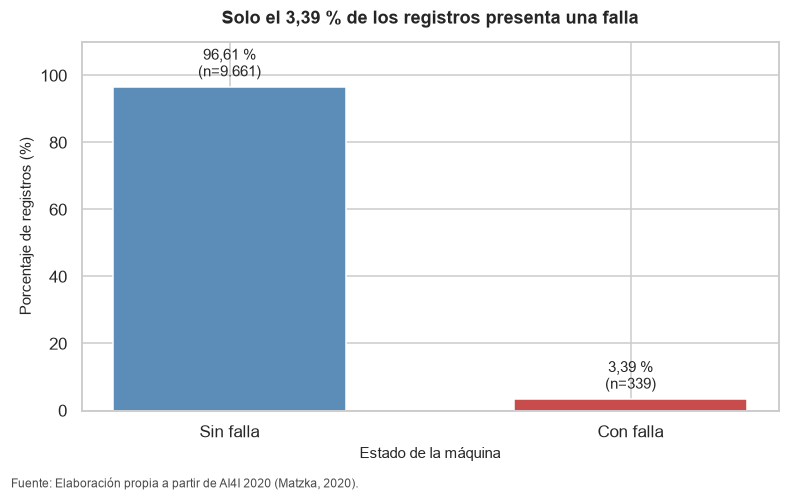

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
datos_balance = resumen_objetivo.reset_index()
barras = ax.bar(
    datos_balance["Estado"],
    datos_balance["porcentaje"],
    color=[PALETA_ESTADO[estado] for estado in datos_balance["Estado"]],
    width=0.58,
)
ax.bar_label(
    barras,
    labels=[
        f"{formato_decimal(porcentaje, 2)} %\n(n={formato_entero(registros)})"
        for porcentaje, registros in zip(
            datos_balance["porcentaje"], datos_balance["registros"]
        )
    ],
    padding=4,
)
ax.set_ylim(0, 110)
rotular_figura(
    fig,
    ax,
    "Solo el 3,39 % de los registros presenta una falla",
    "Estado de la máquina",
    "Porcentaje de registros (%)",
)
fig.tight_layout()
ruta_figura = CARPETA_FIGURAS / "figura_0_balance_objetivo.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
FIGURAS["apoyo_balance"] = ruta_figura
plt.show()


**Qué muestra:** la falla aparece en 339 de 10.000 registros.  
**Qué se infiere:** es una clase poco frecuente y una evaluación predictiva
futura no debería depender solo de la exactitud.  
**Límite:** la figura no indica qué condición origina las fallas.  
**Papel en el relato:** funciona como apoyo para explicar el desbalance antes
de presentar las tres figuras principales.


### Figura 1 — Tasa de falla según el tipo de producto

La primera figura principal incorpora la variable categórica `Type`. La línea
vertical representa la tasa global y permite evaluar si cada grupo queda por
encima o por debajo de ese punto de referencia. H, L y M son los tres códigos
de tipo incluidos en AI4I 2020; se conservan tal como aparecen en el conjunto.


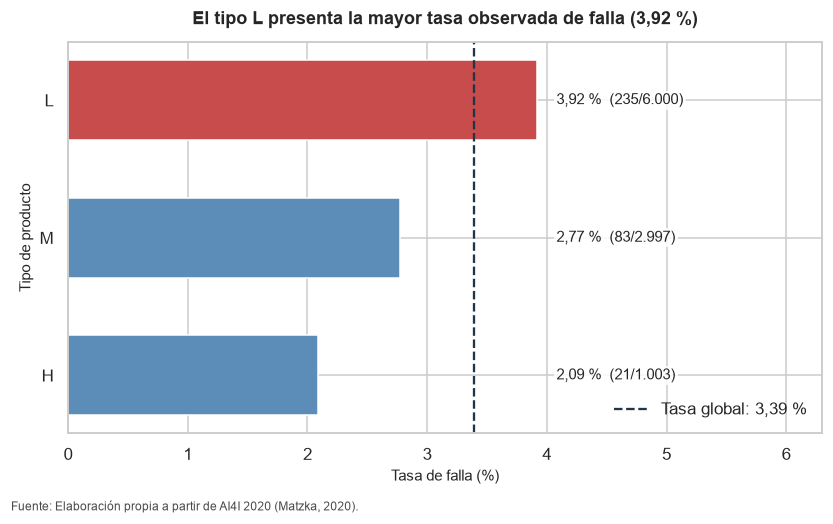

In [13]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
tabla_tipo_figura = tasas_tipo.reset_index().sort_values("tasa_pct")
colores = [
    COLOR_DESTACADO if tipo == "L" else COLOR_BASE
    for tipo in tabla_tipo_figura["Type"]
]
barras = ax.barh(
    tabla_tipo_figura["Type"],
    tabla_tipo_figura["tasa_pct"],
    color=colores,
    height=0.58,
)
for posicion, fila in enumerate(tabla_tipo_figura.itertuples(index=False)):
    ax.text(
        4.08,
        posicion,
        (
            f"{formato_decimal(fila.tasa_pct, 2)} %  "
            f"({formato_entero(fila.fallas)}/{formato_entero(fila.registros)})"
        ),
        va="center",
        ha="left",
        fontsize=9.5,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5},
        zorder=4,
    )
tasa_global = df_visual[OBJETIVO].mean() * 100
ax.axvline(
    tasa_global,
    color=COLOR_OSCURO,
    linestyle="--",
    linewidth=1.5,
    label=f"Tasa global: {formato_decimal(tasa_global, 2)} %",
)
ax.legend(loc="lower right")
ax.set_xlim(0, 6.3)
rotular_figura(
    fig,
    ax,
    "El tipo L presenta la mayor tasa observada de falla (3,92 %)",
    "Tasa de falla (%)",
    "Tipo de producto",
)
fig.tight_layout()
ruta_figura = CARPETA_FIGURAS / "figura_1_tasa_por_tipo.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
FIGURAS[1] = ruta_figura
plt.show()


**Qué muestra:** L presenta 235 fallas entre 6.000 registros y una tasa de
3,92 %, frente a 2,77 % en M y 2,09 % en H.  
**Qué se infiere:** la frecuencia observada no es igual entre los tres tipos.  
**Límite:** el tamaño de los grupos es desigual y la diferencia no demuestra
que el tipo cause una falla.  
**Papel en el relato:** entrega el contexto de comparación mediante la tasa
global y responde la parte categórica del objetivo exploratorio.


### Figura 2 — Recorrido de las cinco variables operacionales

Los cinco paneles muestran la tasa de falla desde el quintil más bajo hasta el
más alto de cada variable. Esta representación conserva las unidades en la
tabla de respaldo y permite comparar la forma de los patrones sin mezclar las
escalas de K, rpm, Nm y minutos.


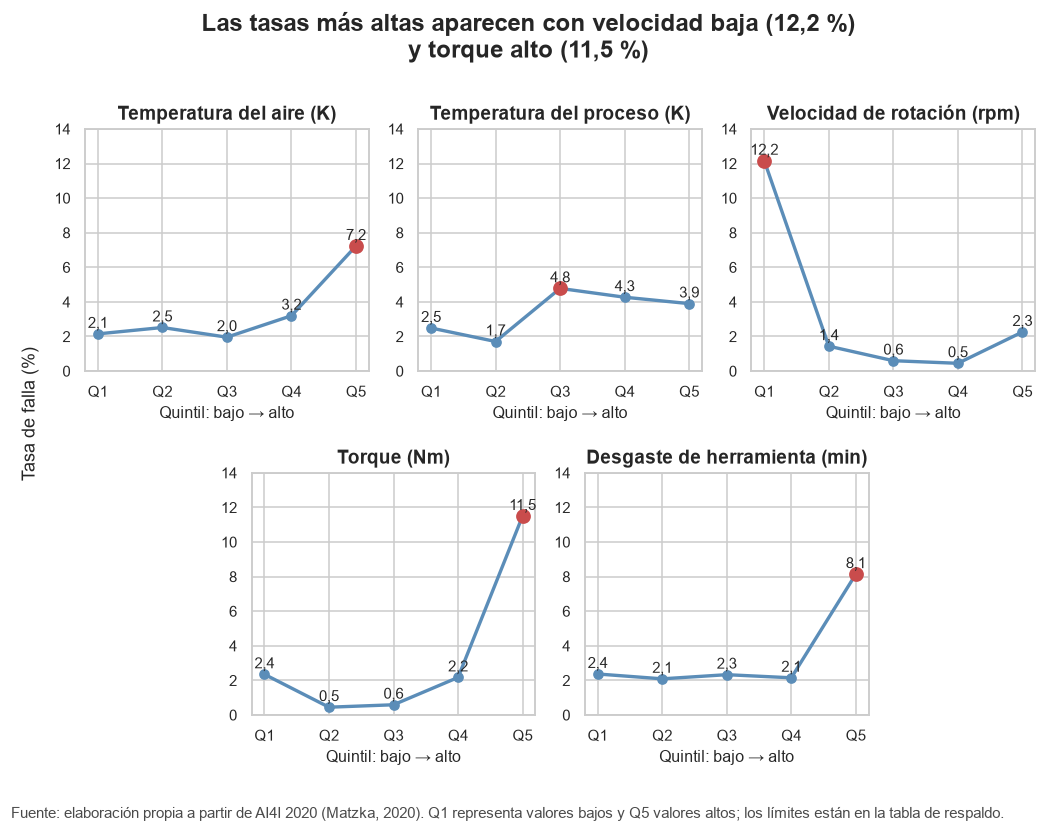

In [14]:
NOMBRES_CORTOS = {
    "Air temperature [K]": "Temperatura del aire (K)",
    "Process temperature [K]": "Temperatura del proceso (K)",
    "Rotational speed [rpm]": "Velocidad de rotación (rpm)",
    "Torque [Nm]": "Torque (Nm)",
    "Tool wear [min]": "Desgaste de herramienta (min)",
}

fig = plt.figure(figsize=(9.6, 7.2))
grilla = fig.add_gridspec(2, 6, hspace=0.42, wspace=0.42)
primer_eje = fig.add_subplot(grilla[0, 0:2])
ejes = [
    primer_eje,
    fig.add_subplot(grilla[0, 2:4], sharey=primer_eje),
    fig.add_subplot(grilla[0, 4:6], sharey=primer_eje),
    fig.add_subplot(grilla[1, 1:3], sharey=primer_eje),
    fig.add_subplot(grilla[1, 3:5], sharey=primer_eje),
]

for indice, columna in enumerate(COLUMNAS_NUMERICAS):
    ax = ejes[indice]
    tabla = tasas_quintiles.query("variable == @columna").copy()
    x = np.arange(1, len(tabla) + 1)
    ax.plot(
        x,
        tabla["tasa_pct"],
        marker="o",
        linewidth=2.2,
        color=COLOR_BASE,
    )
    posicion_maxima = int(tabla["tasa_pct"].idxmax())
    fila_maxima = tasas_quintiles.loc[posicion_maxima]
    indice_local = tabla.index.get_loc(posicion_maxima) + 1
    ax.scatter(
        [indice_local],
        [fila_maxima["tasa_pct"]],
        s=75,
        color=COLOR_DESTACADO,
        zorder=3,
    )
    for numero, tasa in zip(x, tabla["tasa_pct"]):
        ax.text(
            numero,
            tasa + 0.35,
            formato_decimal(tasa, 1),
            ha="center",
            fontsize=10,
        )
    ax.set_title(NOMBRES_CORTOS[columna], fontsize=12.5)
    ax.set_xticks(x, ["Q1", "Q2", "Q3", "Q4", "Q5"])
    ax.set_xlabel("Quintil: bajo → alto", fontsize=10.5)
    ax.tick_params(axis="both", labelsize=10)
    ax.set_ylim(0, 14)

fig.supylabel("Tasa de falla (%)", x=0.02, fontsize=11.5)

tasa_velocidad_baja = tasas_quintiles.query(
    "variable == 'Rotational speed [rpm]' and quintil == 'Q1'"
)["tasa_pct"].iloc[0]
tasa_torque_alto = tasas_quintiles.query(
    "variable == 'Torque [Nm]' and quintil == 'Q5'"
)["tasa_pct"].iloc[0]
fig.suptitle(
    (
        "Las tasas más altas aparecen con velocidad baja "
        f"({formato_decimal(tasa_velocidad_baja, 1)} %)\ny torque alto "
        f"({formato_decimal(tasa_torque_alto, 1)} %)"
    ),
    y=1.01,
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.01,
    -0.01,
    "Fuente: elaboración propia a partir de AI4I 2020 (Matzka, 2020). "
    "Q1 representa valores bajos y Q5 valores altos; los límites están en la tabla de respaldo.",
    fontsize=9.5,
    color="#4A4A4A",
)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.86)
ruta_figura = CARPETA_FIGURAS / "figura_2_tasas_por_quintiles.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
FIGURAS[2] = ruta_figura
plt.show()


**Qué muestra:** la velocidad concentra su mayor tasa en Q1, mientras torque,
desgaste y temperatura del aire la concentran en Q5.  
**Qué se infiere:** los patrones más marcados aparecen con velocidad baja y
torque alto; la temperatura del proceso no presenta un recorrido creciente.  
**Límite:** los quintiles fueron calculados desde este conjunto y no son
umbrales de una máquina real.  
**Papel en el relato:** contrasta las cinco variables y orienta la combinación
que se estudia en la figura siguiente.


### Figura 3 — Interacción entre velocidad, torque y desgaste

La última figura cruza las dos variables con las tasas más extremas y separa
los resultados según desgaste. Los cortes se aprenden solo con entrenamiento:
primer cuartil para velocidad, tercer cuartil para torque y quintil superior
para desgaste. Los cuartiles de velocidad y torque conservan grupos de tamaño
suficiente; el quintil superior de desgaste se utiliza porque la Figura 2
mostró allí su mayor tasa. El mapa se construye con `seaborn.heatmap` siguiendo
su documentación oficial (seaborn development team, 2026).


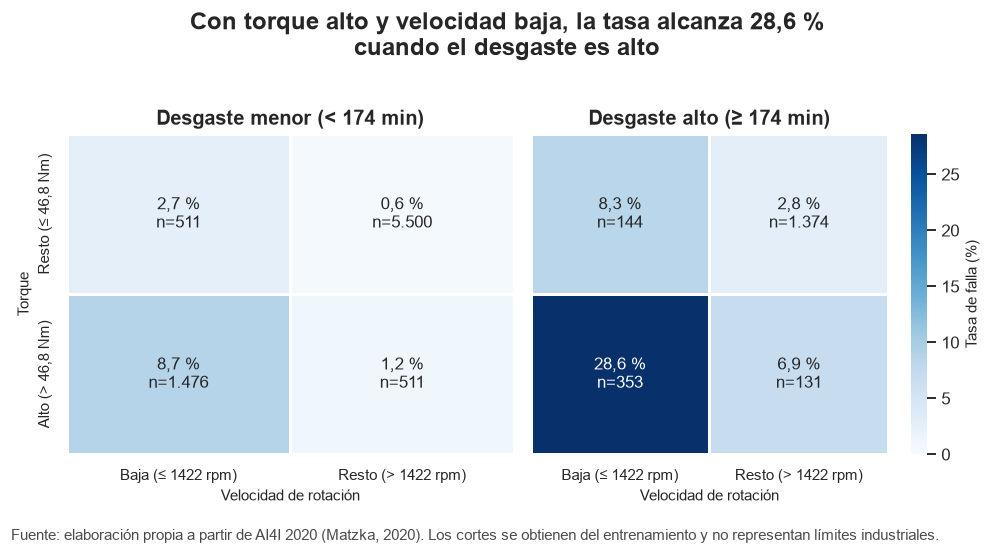

,desgaste_grupo,torque_grupo,velocidad_grupo,registros,fallas,tasa_pct
0,Alto (≥ 174 min),"Alto (> 46,8 Nm)",Baja (≤ 1422 rpm),353,101,28.61
1,Alto (≥ 174 min),"Alto (> 46,8 Nm)",Resto (> 1422 rpm),131,9,6.87
2,Alto (≥ 174 min),"Resto (≤ 46,8 Nm)",Baja (≤ 1422 rpm),144,12,8.33
3,Alto (≥ 174 min),"Resto (≤ 46,8 Nm)",Resto (> 1422 rpm),1374,39,2.84
4,Menor (< 174 min),"Alto (> 46,8 Nm)",Baja (≤ 1422 rpm),1476,128,8.67
5,Menor (< 174 min),"Alto (> 46,8 Nm)",Resto (> 1422 rpm),511,6,1.17
6,Menor (< 174 min),"Resto (≤ 46,8 Nm)",Baja (≤ 1422 rpm),511,14,2.74
7,Menor (< 174 min),"Resto (≤ 46,8 Nm)",Resto (> 1422 rpm),5500,30,0.55


In [15]:
corte_velocidad = float(visual_entrenamiento["Rotational speed [rpm]"].quantile(0.25))
corte_torque = float(visual_entrenamiento["Torque [Nm]"].quantile(0.75))
corte_desgaste = float(visual_entrenamiento["Tool wear [min]"].quantile(0.80))

etiqueta_velocidad_baja = f"Baja (≤ {corte_velocidad:.0f} rpm)"
etiqueta_velocidad_resto = f"Resto (> {corte_velocidad:.0f} rpm)"
etiqueta_torque_alto = f"Alto (> {formato_decimal(corte_torque, 1)} Nm)"
etiqueta_torque_resto = f"Resto (≤ {formato_decimal(corte_torque, 1)} Nm)"
etiqueta_desgaste_alto = f"Alto (≥ {corte_desgaste:.0f} min)"
etiqueta_desgaste_menor = f"Menor (< {corte_desgaste:.0f} min)"

interaccion = df_visual.copy()
interaccion["velocidad_grupo"] = np.where(
    interaccion["Rotational speed [rpm]"] <= corte_velocidad,
    etiqueta_velocidad_baja,
    etiqueta_velocidad_resto,
)
interaccion["torque_grupo"] = np.where(
    interaccion["Torque [Nm]"] > corte_torque,
    etiqueta_torque_alto,
    etiqueta_torque_resto,
)
interaccion["desgaste_grupo"] = np.where(
    interaccion["Tool wear [min]"] >= corte_desgaste,
    etiqueta_desgaste_alto,
    etiqueta_desgaste_menor,
)

tabla_interaccion = (
    interaccion.groupby(
        ["desgaste_grupo", "torque_grupo", "velocidad_grupo"],
        observed=True,
    )[OBJETIVO]
    .agg(registros="size", fallas="sum", tasa="mean")
    .reset_index()
)
tabla_interaccion["tasa_pct"] = (tabla_interaccion["tasa"] * 100).round(2)

orden_desgaste = [
    etiqueta_desgaste_menor,
    etiqueta_desgaste_alto,
]
orden_torque = [
    etiqueta_torque_resto,
    etiqueta_torque_alto,
]
orden_velocidad = [
    etiqueta_velocidad_baja,
    etiqueta_velocidad_resto,
]

maximo_interaccion = tabla_interaccion["tasa_pct"].max()
fig, ejes = plt.subplots(1, 2, figsize=(9.2, 4.5), sharey=True)

for indice, desgaste in enumerate(orden_desgaste):
    subconjunto = tabla_interaccion.query("desgaste_grupo == @desgaste")
    tasas = (
        subconjunto.pivot(
            index="torque_grupo",
            columns="velocidad_grupo",
            values="tasa_pct",
        )
        .reindex(index=orden_torque, columns=orden_velocidad)
    )
    cantidades = (
        subconjunto.pivot(
            index="torque_grupo",
            columns="velocidad_grupo",
            values="registros",
        )
        .reindex(index=orden_torque, columns=orden_velocidad)
    )
    anotaciones = tasas.copy().astype(object)
    for fila in tasas.index:
        for columna in tasas.columns:
            anotaciones.loc[fila, columna] = (
                f"{formato_decimal(tasas.loc[fila, columna], 1)} %\n"
                f"n={formato_entero(cantidades.loc[fila, columna])}"
            )
    sns.heatmap(
        tasas,
        annot=anotaciones,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=maximo_interaccion,
        linewidths=0.8,
        linecolor="white",
        cbar=indice == 1,
        cbar_kws={"label": "Tasa de falla (%)"},
        annot_kws={"size": 11},
        ax=ejes[indice],
    )
    ejes[indice].set_title(f"Desgaste {desgaste.lower()}", fontsize=13)
    ejes[indice].set_xlabel("Velocidad de rotación")
    ejes[indice].set_ylabel("Torque" if indice == 0 else "")
    ejes[indice].tick_params(axis="both", labelsize=10)

fig.suptitle(
    (
        "Con torque alto y velocidad baja, la tasa alcanza "
        f"{formato_decimal(maximo_interaccion, 1)} %\ncuando el desgaste es alto"
    ),
    y=1.03,
    fontsize=15.5,
    fontweight="bold",
)
fig.text(
    0.01,
    -0.04,
    "Fuente: elaboración propia a partir de AI4I 2020 (Matzka, 2020). "
    "Los cortes se obtienen del entrenamiento y no representan límites industriales.",
    fontsize=9.5,
    color="#4A4A4A",
)
fig.tight_layout()
ruta_figura = CARPETA_FIGURAS / "figura_3_interaccion_operacional.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
FIGURAS[3] = ruta_figura
plt.show()

display(tabla_interaccion.drop(columns="tasa"))


**Qué muestra:** el mayor porcentaje aparece cuando coinciden velocidad baja,
torque alto y desgaste alto.  
**Qué se infiere:** esa combinación define el perfil con mayor frecuencia
observada entre los segmentos comparados.  
**Límite:** el perfil se eligió después de la exploración y no demuestra
causalidad ni desempeño predictivo en una planta industrial.  
**Papel en el relato:** resuelve la pregunta principal al integrar tres
condiciones, pero requiere una comprobación separada en prueba.


### 6.1 Validación descriptiva en entrenamiento y prueba

Los cortes de la Figura 3 se calcularon únicamente con entrenamiento. Ahora se
aplican sin cambios a entrenamiento y prueba para comprobar si la diferencia
descriptiva se mantiene en datos separados. Esta validación no es un modelo:
no calcula precisión, sensibilidad ni capacidad de predicción individual.


In [16]:
def evaluar_perfil(datos, particion):
    '''Compara el perfil combinado con el resto de una partición.'''
    es_perfil = (
        datos["Rotational speed [rpm]"].le(corte_velocidad)
        & datos["Torque [Nm]"].gt(corte_torque)
        & datos["Tool wear [min]"].ge(corte_desgaste)
    )
    filas = []
    for grupo, mascara in (
        ("Perfil combinado", es_perfil),
        ("Resto", ~es_perfil),
    ):
        subconjunto = datos.loc[mascara, OBJETIVO]
        filas.append({
            "particion": particion,
            "grupo": grupo,
            "registros": int(len(subconjunto)),
            "fallas": int(subconjunto.sum()),
            "tasa_pct": round(float(subconjunto.mean() * 100), 2),
        })
    return pd.DataFrame(filas)


validacion_perfil = pd.concat([
    evaluar_perfil(visual_entrenamiento, "Entrenamiento"),
    evaluar_perfil(visual_prueba, "Prueba"),
], ignore_index=True)

tabla_validacion = validacion_perfil.pivot(
    index="particion", columns="grupo", values="tasa_pct"
)
assert (tabla_validacion["Perfil combinado"] > tabla_validacion["Resto"]).all()

display(validacion_perfil)
print(
    "[OK] El perfil mantiene una tasa observada mayor que el resto "
    "en entrenamiento y prueba."
)


,particion,grupo,registros,fallas,tasa_pct
0,Entrenamiento,Perfil combinado,273,79,28.94
1,Entrenamiento,Resto,7727,192,2.48
2,Prueba,Perfil combinado,80,22,27.50
3,Prueba,Resto,1920,46,2.40


[OK] El perfil mantiene una tasa observada mayor que el resto en entrenamiento y prueba.


En entrenamiento, el perfil reúne 79 fallas entre 273 registros (28,94 %),
frente a 192 entre 7.727 en el resto (2,48 %). En prueba, reúne 22 fallas entre
80 registros (27,50 %), frente a 46 entre 1.920 (2,40 %). La cercanía de las
tasas entre ambas particiones fortalece la observación descriptiva, aunque no
la convierte en una regla predictiva ni en un umbral industrial.


### 6.2 Correspondencia entre objetivos y figuras

La tabla siguiente comprueba que las figuras principales aporten respuestas
diferentes y que la figura de apoyo cumpla una función concreta.


In [17]:
mapa_figuras = pd.DataFrame([
    {
        "figura": "Apoyo",
        "objetivo_F1": "OE1: caracterizar variables operacionales y la variable de falla",
        "pregunta": "¿Cuál es la magnitud general de las fallas?",
        "aporte": "Documenta el desbalance 9.661 frente a 339.",
        "uso": "Notebook y posible anexo",
    },
    {
        "figura": "Figura 1",
        "objetivo_F1": "OE4: explorar la relación entre Type y la ocurrencia de fallas",
        "pregunta": "¿La tasa cambia según Type?",
        "aporte": "Compara H, M y L con la tasa global.",
        "uso": "Notebook, informe y presentación",
    },
    {
        "figura": "Figura 2",
        "objetivo_F1": "OE4: explorar la relación entre las cinco variables y las fallas",
        "pregunta": "¿Cómo varía la tasa en las cinco mediciones?",
        "aporte": "Cubre todas las variables operacionales mediante quintiles.",
        "uso": "Notebook, informe y presentación",
    },
    {
        "figura": "Figura 3",
        "objetivo_F1": "OE5: evaluar si las variables permiten reconocer situaciones de mayor riesgo",
        "pregunta": "¿Qué combinación concentra más fallas?",
        "aporte": "Integra velocidad, torque y desgaste.",
        "uso": "Notebook, informe y presentación",
    },
])

assert len(FIGURAS) == 4
assert all(Path(ruta).is_file() for ruta in FIGURAS.values())
display(mapa_figuras)


,figura,objetivo_F1,pregunta,aporte,uso
0,Apoyo,OE1: caracterizar variables operacionales y la...,¿Cuál es la magnitud general de las fallas?,Documenta el desbalance 9.661 frente a 339.,Notebook y posible anexo
1,Figura 1,OE4: explorar la relación entre Type y la ocur...,¿La tasa cambia según Type?,"Compara H, M y L con la tasa global.","Notebook, informe y presentación"
2,Figura 2,OE4: explorar la relación entre las cinco vari...,¿Cómo varía la tasa en las cinco mediciones?,Cubre todas las variables operacionales median...,"Notebook, informe y presentación"
3,Figura 3,OE5: evaluar si las variables permiten reconoc...,¿Qué combinación concentra más fallas?,"Integra velocidad, torque y desgaste.","Notebook, informe y presentación"


## 7. Metodología del cierre

El desarrollo siguió seis decisiones principales:

1. Se conservaron sin cambios los conjuntos de entrenamiento y prueba de F3.
2. Se recuperaron unidades y categorías mediante los parámetros guardados, sin
   volver a ajustar el pipeline.
3. La copia interpretable se comparó con las siete variables analíticas del
   archivo original, sin depender del orden de las filas.
4. La exploración se organizó desde la pregunta y los objetivos de F1.
5. Los cortes de la interacción se calcularon con entrenamiento y se aplicaron
   sin cambios a prueba.
6. Cada visualización se acompañó de una inferencia, una limitación y su papel
   en el relato.

La secuencia narrativa de las tres figuras principales es **contexto,
contraste y resolución**: la Figura 1 compara los tipos con la tasa global, la
Figura 2 recorre las cinco mediciones y la Figura 3 examina una combinación
operacional. La figura del desbalance queda como apoyo del notebook.


## 8. Resultados

Los resultados principales son los siguientes:

- `Machine failure` aparece en 339 de 10.000 registros, equivalentes al 3,39 %.
- El tipo L presenta una tasa observada superior a M y H.
- Los extremos más claros aparecen en velocidad baja, torque alto, desgaste
  alto y temperatura del aire alta.
- La temperatura del proceso no sigue un aumento continuo entre quintiles.
- La combinación de velocidad baja, torque alto y desgaste alto concentra la
  mayor tasa dentro de los segmentos examinados.
- Con cortes obtenidos desde entrenamiento, el perfil combinado alcanza 28,94 %
  en entrenamiento y 27,50 % en prueba; el resto registra 2,48 % y 2,40 %.

Las cifras detalladas se conservan en las tablas generadas por el código. De
esta forma, las cifras escritas quedan respaldadas por productos verificables.


## 9. Discusión y reflexión técnica

Los hallazgos son coherentes con la pregunta del proyecto porque muestran que
la tasa de falla no se distribuye de forma uniforme. Torque, velocidad y
desgaste aportan señales descriptivas más claras que la temperatura del
proceso. El tipo de producto también presenta diferencias, aunque sus grupos
tienen tamaños distintos.

La interpretación tiene límites importantes. AI4I 2020 es sintético, la clase
positiva representa solo el 3,39 %, los cortes utilizados son cuantiles del
entrenamiento y no existe una validación con maquinaria real. El perfil
combinado surgió después de explorar los datos, por lo que su comparación entre
entrenamiento y prueba es una confirmación descriptiva posterior. Además, este
cuaderno no entrena un clasificador. Por ello, se puede afirmar que existen
asociaciones y perfiles con mayor tasa observada, pero no que las variables
causen o predigan una falla con un desempeño determinado.

Para el cierre descriptivo se reunieron entrenamiento y prueba después de
conservar la columna `particion`. Esto permite comunicar las 10.000
observaciones sin volver a ajustar transformaciones. Si se desarrollara un
modelo en el futuro, debería reservarse una nueva validación o definirse el
procedimiento antes de inspeccionar el conjunto de prueba.

Una mejora futura sería evaluar un modelo sencillo sobre la partición de prueba
de F3 y utilizar sensibilidad, precisión, F1 y PR-AUC. La exactitud por sí sola
sería insuficiente debido al desbalance.


## 10. Conclusiones

El proyecto identificó diferencias en la frecuencia de fallas según el tipo de
producto y las condiciones operacionales. La velocidad baja y el torque alto
presentaron los patrones individuales más marcados, y su combinación con un
desgaste elevado definió el segmento con mayor tasa observada.

F4 mantuvo la trazabilidad del proceso al utilizar los cuatro artefactos de F3,
recuperar las unidades mediante parámetros aprendidos únicamente desde
entrenamiento y comprobar la equivalencia con el archivo original. Esta
separación evitó modificar los datos preparados para análisis y permitió
construir gráficos comprensibles.

Las conclusiones se restringen al conjunto AI4I 2020. Los resultados permiten
reconocer un perfil con mayor frecuencia observada de fallas, pero la capacidad
predictiva formal y la generalización a un entorno industrial real quedan como
trabajo posterior. De este modo, se cubre la parte descriptiva del objetivo
general y queda pendiente su evaluación predictiva.


## 11. Trazabilidad de mejoras

La tabla vincula observaciones de las fases anteriores con la acción aplicada
y su efecto. El `changelog.md` del repositorio incorporará posteriormente los
hashes reales de los commits; no se registran identificadores pendientes o
inventados dentro del notebook.


In [18]:
trazabilidad_mejoras = pd.DataFrame([
    {
        "origen": "Retroalimentación F1-F2",
        "observacion": "AI4I es sintético y no presenta problemas reales de limpieza.",
        "accion": "Se mantuvo el conjunto autorizado sin introducir nulos o duplicados artificiales.",
        "evidencia": "Validación de F1 y F2; discusión de F4.",
        "impacto": "Las limitaciones quedan declaradas con honestidad.",
    },
    {
        "origen": "F2 a F3",
        "observacion": "Las transformaciones que aprenden parámetros deben ajustarse con entrenamiento.",
        "accion": "F3 dividió antes de ajustar el codificador y los escaladores.",
        "evidencia": "Pipeline modular y parámetros persistidos en F3.",
        "impacto": "Se evita que prueba participe en el ajuste.",
    },
    {
        "origen": "F3 a F4",
        "observacion": "Los datos escalados y One Hot no son adecuados para comunicar resultados.",
        "accion": "Se creó una copia interpretable mediante inversión de RobustScaler y reconstrucción de Type.",
        "evidencia": "Sección 4 y comparación formal con F1.",
        "impacto": "Los gráficos recuperan K, rpm, Nm, minutos y categorías.",
    },
    {
        "origen": "Cierre F4",
        "observacion": "Las figuras deben responder a los objetivos y declarar límites.",
        "accion": "Se organizaron cuatro figuras y tres principales con narrativa contexto-contraste-resolución.",
        "evidencia": "Sección 6 y mapa de correspondencia.",
        "impacto": "Cada conclusión puede rastrearse hasta una tabla o figura.",
    },
])

display(trazabilidad_mejoras)


,origen,observacion,accion,evidencia,impacto
0,Retroalimentación F1-F2,AI4I es sintético y no presenta problemas real...,Se mantuvo el conjunto autorizado sin introduc...,Validación de F1 y F2; discusión de F4.,Las limitaciones quedan declaradas con honesti...
1,F2 a F3,Las transformaciones que aprenden parámetros d...,F3 dividió antes de ajustar el codificador y l...,Pipeline modular y parámetros persistidos en F3.,Se evita que prueba participe en el ajuste.
2,F3 a F4,Los datos escalados y One Hot no son adecuados...,Se creó una copia interpretable mediante inver...,Sección 4 y comparación formal con F1.,"Los gráficos recuperan K, rpm, Nm, minutos y c..."
3,Cierre F4,Las figuras deben responder a los objetivos y ...,Se organizaron cuatro figuras y tres principal...,Sección 6 y mapa de correspondencia.,Cada conclusión puede rastrearse hasta una tab...


## 12. Persistencia de productos

Se guardan la copia interpretable, las tablas que sostienen las cifras, la
trazabilidad y los metadatos. También se calculan huellas SHA-256 abreviadas de
los cuatro archivos recibidos desde F3 para identificar exactamente las
entradas utilizadas.


In [19]:
def calcular_hash(ruta):
    '''Calcula SHA-256 de un archivo sin cargarlo completo en memoria.'''
    huella = hashlib.sha256()
    with Path(ruta).open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(8192), b""):
            huella.update(bloque)
    return huella.hexdigest()


SALIDAS = {
    "datos_visualizacion": CARPETA_DATOS / "ai4i2020_visualizacion.csv",
    "resumen_objetivo": CARPETA_DOCS / "resumen_objetivo.csv",
    "tasas_tipo": CARPETA_DOCS / "tasas_tipo_producto.csv",
    "resumen_variables": CARPETA_DOCS / "resumen_variables_operacionales.csv",
    "tasas_quintiles": CARPETA_DOCS / "tasas_quintiles.csv",
    "interaccion": CARPETA_DOCS / "interaccion_operacional.csv",
    "validacion_perfil": CARPETA_DOCS / "validacion_perfil.csv",
    "trazabilidad": CARPETA_DOCS / "trazabilidad_mejoras.csv",
    "mapa_figuras": CARPETA_DOCS / "mapa_objetivos_figuras.csv",
    "metadatos": CARPETA_DOCS / "metadatos_fase4.json",
}

df_visual.to_csv(SALIDAS["datos_visualizacion"], index=False, encoding="utf-8-sig")
resumen_objetivo.reset_index().to_csv(SALIDAS["resumen_objetivo"], index=False, encoding="utf-8-sig")
tasas_tipo.reset_index().to_csv(SALIDAS["tasas_tipo"], index=False, encoding="utf-8-sig")
resumen_variables.to_csv(SALIDAS["resumen_variables"], index=False, encoding="utf-8-sig")
tasas_quintiles.to_csv(SALIDAS["tasas_quintiles"], index=False, encoding="utf-8-sig")
tabla_interaccion.drop(columns="tasa").to_csv(SALIDAS["interaccion"], index=False, encoding="utf-8-sig")
validacion_perfil.to_csv(SALIDAS["validacion_perfil"], index=False, encoding="utf-8-sig")
trazabilidad_mejoras.to_csv(SALIDAS["trazabilidad"], index=False, encoding="utf-8-sig")
mapa_figuras.to_csv(SALIDAS["mapa_figuras"], index=False, encoding="utf-8-sig")

metadatos_f4 = {
    "proyecto": "Análisis de condiciones operacionales y fallas con AI4I 2020",
    "fase": "F4",
    "grupo": 9,
    "autor": "Alexander Sepúlveda Ormazábal",
    "fecha_ejecucion": date.today().isoformat(),
    "semilla": SEMILLA,
    "filas": int(len(df_visual)),
    "fallas": int(df_visual[OBJETIVO].sum()),
    "figuras_generadas": {str(clave): str(ruta.relative_to(RAIZ)) for clave, ruta in FIGURAS.items()},
    "entradas_f3": {
        nombre: {
            "ruta": str(ARCHIVOS[nombre].relative_to(RAIZ)),
            "sha256": calcular_hash(ARCHIVOS[nombre]),
        }
        for nombre in ("entrenamiento", "prueba", "diccionario", "parametros")
    },
    "validacion_descriptiva": {
        "cortes_calculados_con": "entrenamiento",
        "velocidad_maxima_rpm": corte_velocidad,
        "torque_minimo_nm": corte_torque,
        "desgaste_minimo_min": corte_desgaste,
        "tasas_por_particion": validacion_perfil.to_dict(orient="records"),
    },
    "limitaciones": [
        "AI4I 2020 es sintético.",
        "La clase de falla representa 3,39 %.",
        "Los cortes son cuantiles descriptivos.",
        "No se evaluó un modelo predictivo.",
        "Las asociaciones no demuestran causalidad.",
    ],
}

SALIDAS["metadatos"].write_text(
    json.dumps(metadatos_f4, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

productos = pd.DataFrame([
    {
        "producto": nombre,
        "ruta": str(ruta.relative_to(RAIZ)),
        "existe": ruta.is_file(),
    }
    for nombre, ruta in {**SALIDAS, **{f"figura_{k}": v for k, v in FIGURAS.items()}}.items()
])
display(productos)


,producto,ruta,existe
0,datos_visualizacion,F4\data\processed\ai4i2020_visualizacion.csv,True
1,resumen_objetivo,F4\docs\resumen_objetivo.csv,True
2,tasas_tipo,F4\docs\tasas_tipo_producto.csv,True
3,resumen_variables,F4\docs\resumen_variables_operacionales.csv,True
4,tasas_quintiles,F4\docs\tasas_quintiles.csv,True
5,interaccion,F4\docs\interaccion_operacional.csv,True
6,validacion_perfil,F4\docs\validacion_perfil.csv,True
7,trazabilidad,F4\docs\trazabilidad_mejoras.csv,True
8,mapa_figuras,F4\docs\mapa_objetivos_figuras.csv,True
9,metadatos,F4\docs\metadatos_fase4.json,True


## 13. Verificación final

La última celda vuelve a leer los productos principales y calcula cada estado
desde los archivos y resultados obtenidos. La ejecución solo termina con el
mensaje final cuando todas las condiciones se cumplen.


In [20]:
datos_guardados = pd.read_csv(SALIDAS["datos_visualizacion"], encoding="utf-8-sig")

condiciones = [
    ("Entorno virtual activo", sys.prefix != sys.base_prefix),
    ("Cuatro artefactos de F3 disponibles", all(ARCHIVOS[n].is_file() for n in ("entrenamiento", "prueba", "diccionario", "parametros"))),
    ("10.000 registros conservados", len(datos_guardados) == 10000),
    ("339 fallas conservadas", int(datos_guardados[OBJETIVO].sum()) == 339),
    ("Sin valores faltantes nuevos", int(datos_guardados.isna().sum().sum()) == 0),
    ("Categorías H, L y M recuperadas", set(datos_guardados["Type"].unique()) == {"H", "L", "M"}),
    ("Equivalencia con F1 comprobada", visual_ordenado.equals(referencia_ordenada)),
    ("Cuatro figuras exportadas", len(FIGURAS) == 4 and all(Path(ruta).is_file() for ruta in FIGURAS.values())),
    ("Tres figuras principales documentadas", all(numero in FIGURAS for numero in (1, 2, 3))),
    ("Pruebas y eficiencia de F3 integradas", pruebas_f3["estado"].eq("OK").all() and len(crecimiento_temporal) == 4),
    ("Perfil validado en ambas particiones", (tabla_validacion["Perfil combinado"] > tabla_validacion["Resto"]).all()),
    ("Tablas de respaldo guardadas", all(ruta.is_file() for ruta in SALIDAS.values())),
    ("Objetivos vinculados con figuras", len(mapa_figuras) == 4),
]

verificacion_final = pd.DataFrame([
    {"control": nombre, "estado": "OK" if condicion else "FALLA"}
    for nombre, condicion in condiciones
])
display(verificacion_final)

fallas_verificacion = verificacion_final.query("estado != 'OK'")
if not fallas_verificacion.empty:
    raise AssertionError(
        "La verificación final detectó controles pendientes: "
        + ", ".join(fallas_verificacion["control"])
    )

print("[OK] La Fase 4 superó la verificación final.")
print("[OK] Los resultados pueden utilizarse en el informe y la presentación.")


,control,estado
0,Entorno virtual activo,OK
1,Cuatro artefactos de F3 disponibles,OK
2,10.000 registros conservados,OK
3,339 fallas conservadas,OK
4,Sin valores faltantes nuevos,OK
5,"Categorías H, L y M recuperadas",OK
6,Equivalencia con F1 comprobada,OK
7,Cuatro figuras exportadas,OK
8,Tres figuras principales documentadas,OK
9,Pruebas y eficiencia de F3 integradas,OK


[OK] La Fase 4 superó la verificación final.
[OK] Los resultados pueden utilizarse en el informe y la presentación.


## 14. Referencias

- Matzka, S. (2020). *AI4I 2020 Predictive Maintenance Dataset* [Conjunto
  de datos]. UCI Machine Learning Repository.
  https://doi.org/10.24432/C5HS5C
- Phan, T. L. J., Gehrhardt, I., Heik, D., Bahrpeyma, F., y Reichelt, D.
  (2022). A systematic mapping study on machine learning techniques applied
  for condition monitoring and predictive maintenance in the manufacturing
  sector. *Logistics, 6*(2), 35. https://doi.org/10.3390/logistics6020035
- pandas development team. (2026). *pandas.qcut*. pandas documentation.
  https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
- seaborn development team. (2026). *seaborn.heatmap*. seaborn documentation.
  https://seaborn.pydata.org/generated/seaborn.heatmap.html
- Universidad Andrés Bello. (2026a). *Guía de apoyo Sumativa 3 Fase 4*
  [Documento de apoyo docente]. MCDI500 Programación para la Ciencia de Datos.
- Universidad Andrés Bello. (2026b). *MCDI500 Apunte Fase 4* [Material de
  clase]. MCDI500 Programación para la Ciencia de Datos.

Las fuentes técnicas sustentan la preparación y las visualizaciones; las
conclusiones numéricas provienen exclusivamente de las salidas ejecutadas en
este cuaderno.
